In [1]:
#importing libraries
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#set random seet for reproducibility
tf.random.set_seed(42)

In [3]:
#loading dataset
(X_train,Y_train),(X_test,Y_test) =fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
#printing shapes of the dataset
print('Training data shape:',X_train.shape)
print('Test data shape:',X_test.shape)
print('Training labels shape:',Y_train.shape)
print('Test labels shape:',Y_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)


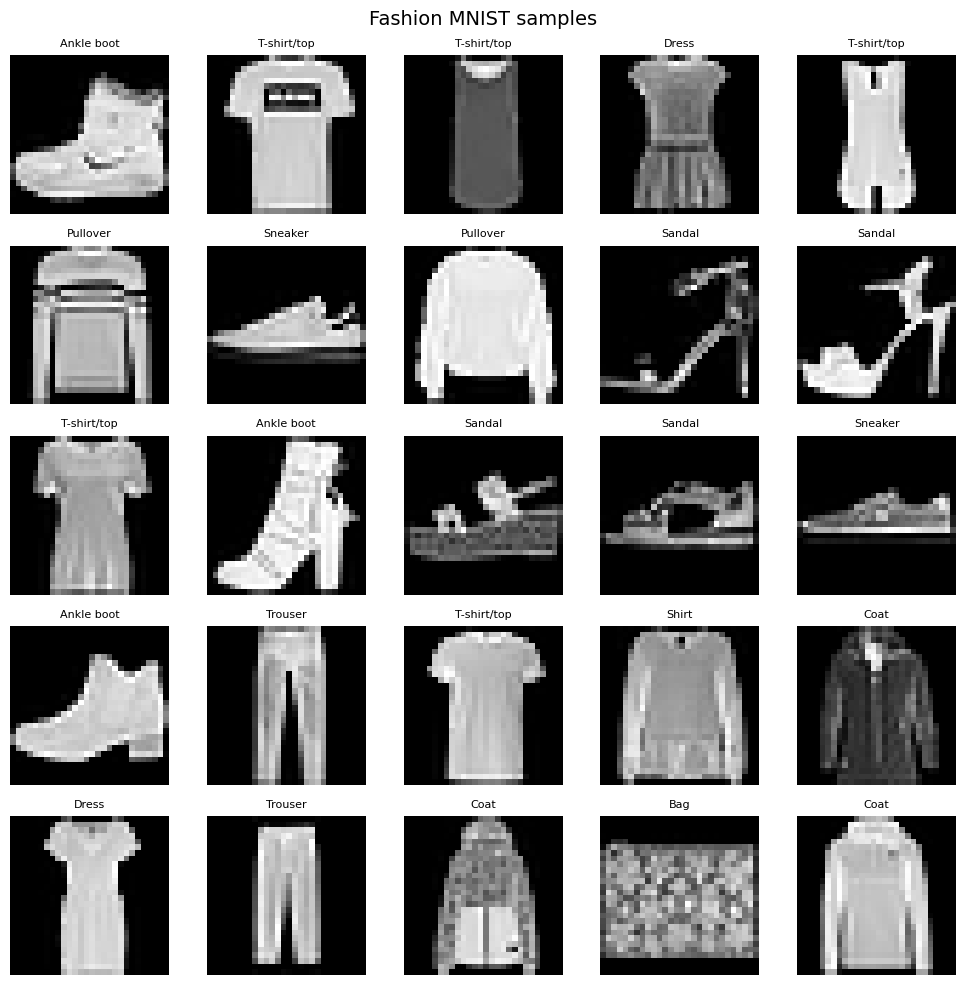

In [5]:
#define class names for the labels
class_names =['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
#plot 25 imags from the dataset
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5, i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(class_names[Y_train[i]],fontsize=8)
  plt.axis('off')
plt.suptitle('Fashion MNIST samples',fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
#normalize the pixel value to [0 1]
X_train = X_train.astype('float32')/225.0
X_test = X_test.astype('float32')/225.0

In [7]:
#reshape data to add channel dimension (28,28,1)
X_train = X_train[...,np.newaxis]
X_test = X_test[...,np.newaxis]

In [8]:
print('New shape of training dataset:',X_train.shape)

New shape of training dataset: (60000, 28, 28, 1)


In [11]:
#Build a sequential CNN model
model = models.Sequential([
    # Input layer specifying the shape of input images (28x28 pixels, 1 channel for grayscale)
    Input(shape = (28,28,1)),
    # First convolutional layer with 32 filters of size 3x3 and ReLU activation
    layers.Conv2D(32,(3,3),activation='relu'),
    # First max pooling layer to reduce spatial dimensions (downsampling)
    layers.MaxPooling2D((2,2)),
    # Second convolutional layer with 64 filters of size 3x3 and ReLU activation
    layers.Conv2D(64,(3,3),activation='relu'),
    # Second max pooling layer for further downsampling
    layers.MaxPool2D((2,2)),
    # Flatten the 2D feature maps into a 1D feature vector
    layers.Flatten(),
    # Fully connected dense layer with 128 neurons and ReLU activation
    layers.Dense(128,activation='relu'),
    # Dropout layer to reduce overfitting by randomly setting 30% of neurons to 0 during training
    layers.Dropout(0.3),
    # Output layer with 10 neurons (one for each class) and softmax activation to output probabilities
    layers.Dense(10,activation='softmax')
])

#compile the model
model.compile(
    optimizer = 'adam',   # Adam optimizer adjusts learning rate during training
    loss = 'sparse_categorical_crossentropy',# Use this when labels are integers (not one-hot)
    metrics = ['accuracy']
)
#display the summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#train the model
history = model.fit(
    X_train,
    Y_train,
    epochs = 10,
    validation_data = (X_test,Y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.7578 - loss: 0.6775 - val_accuracy: 0.8741 - val_loss: 0.3462
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 29ms/step - accuracy: 0.8743 - loss: 0.3502 - val_accuracy: 0.8881 - val_loss: 0.3048
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8907 - loss: 0.2980 - val_accuracy: 0.8983 - val_loss: 0.2791
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9003 - loss: 0.2656 - val_accuracy: 0.9017 - val_loss: 0.2667
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 29ms/step - accuracy: 0.9116 - loss: 0.2385 - val_accuracy: 0.9049 - val_loss: 0.2657
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.9177 - loss: 0.2181 - val_accuracy: 0.9063 - val_loss: 0.2596
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 29ms/step - accuracy: 0.9249 - loss: 0.1977 - val_accuracy: 0.9067 - val_loss: 0.2605
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9301 -

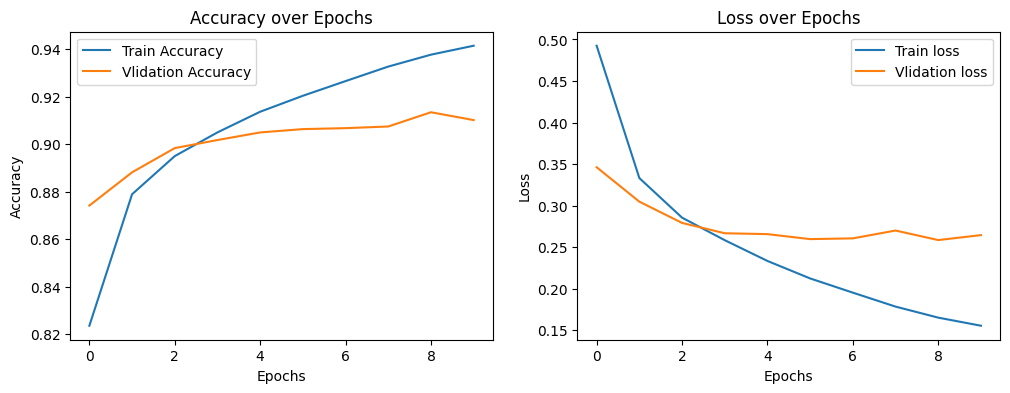

In [13]:
#plot training vs validation acuracy and loss
plt.figure(figsize=(12,4))

#Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Vlidation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Train loss')
plt.plot(history.history['val_loss'], label = 'Vlidation loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
#Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test,Y_test)
print('Test Accuracy',test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9086 - loss: 0.2769
Test Accuracy 0.910099983215332


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


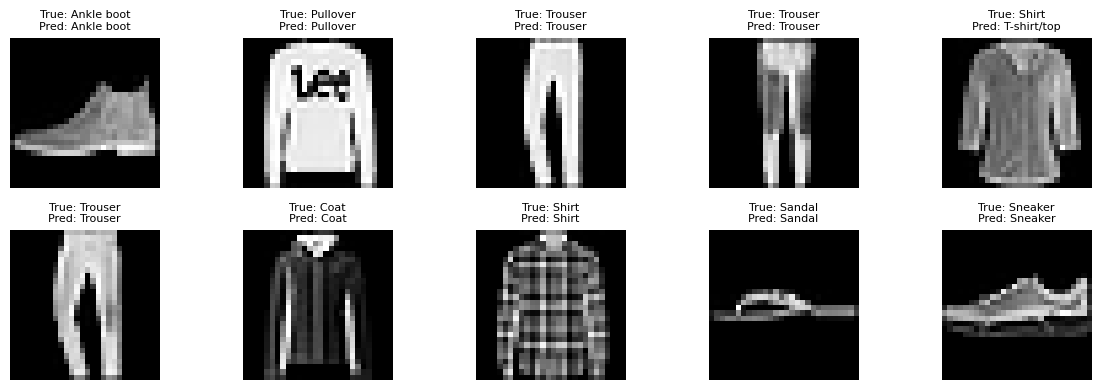

In [16]:
#predict first 10 test samples
prediction = model.predict(X_test[:10])
predicted_labels = np.argmax(prediction, axis=1)

#display Predictions
plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,5, i+1)
  plt.imshow(X_test[i].squeeze(),cmap='gray')
  plt.title(f'True: {class_names[Y_test[i]]}\nPred: {class_names[predicted_labels[i]]}',fontsize=8)
  plt.axis('off')
plt.tight_layout()
plt.show()